# Diabetes Transitional Care Resource Allocation System

**Business analytics final project:** A decision-support prototype for prioritizing post-discharge care among patients with diabetes.

This notebook follows the final-project instructions and my proposal: **The Capacity Problem: Transitional Care Triage for Patients With Diabetes**. The work is framed around a hospital care-management decision, not just a prediction task: **which patients should receive scarce transitional-care resources, what level of support should they receive, and what financial or operational value could that targeting create?**

The technical path is:

1. Clean and explore the UCI Diabetes 130-US Hospitals dataset.
2. Use prior case-study cleaning patterns, including `?` handling, high-missingness review, near-zero-variance medication review, age encoding, medication encoding, and ICD-9 chapter grouping.
3. Predict 30-day readmission risk for eligible discharge encounters while preventing the same patient from appearing in both training and testing.
4. Translate risk scores into intervention tiers and capacity-constrained patient lists.
5. Estimate cost, savings, break-even assumptions, and resource impact.
6. Save a reusable model artifact and app-ready sample files.
7. Document the RAG component, completed fine-tuned-model comparison, Hugging Face Space app structure, executive communication, and reflection pieces for the final deliverable.


## Core Business Problem

Hospitals have limited staff, time, and funding for post-discharge care. Many patients with diabetes may benefit from additional support, but the care-management team cannot provide intensive follow-up to everyone.

**Decision being supported:** Which diabetic patients should receive routine discharge support, enhanced follow-up, or intensive transitional-care intervention?

**Primary stakeholder:** Hospital Director of Care Management or Transitional Care Manager.

**Target outcome:** Maximize expected net value from transitional-care interventions while maintaining acceptable recall for 30-day readmissions.

This makes the project a **resource-allocation problem**. The model should rank patients by readmission risk, connect risk to intervention capacity and cost assumptions, and give stakeholders a plain-language explanation of why a patient or patient segment is high priority.


## 1. Python Setup


In [ ]:

import warnings
warnings.filterwarnings("ignore")

import csv
import json
import re
from pathlib import Path
import pickle

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_PLOTTING = True
except ImportError:
    plt = None
    HAS_PLOTTING = False
    print("matplotlib not installed; tables will run and plots will be skipped.")

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    sns = None
    HAS_SEABORN = False
    print("seaborn not installed; using matplotlib-only charts where possible.")

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)

RANDOM_STATE = 42
PROJECT_DIR = Path.cwd()

# Make the notebook reproducible whether it is opened from the project root or a different working directory.
if not (PROJECT_DIR / "data" / "diabetic_data.csv").exists():
    PROJECT_DIR = Path("/Users/chloebarker/GitHub/SMU-materials/decision-analytics/final-project")

DATA_DIR = PROJECT_DIR / "data"
APP_DIR = PROJECT_DIR / "app"
ARTIFACT_DIR = APP_DIR / "artifacts" if APP_DIR.exists() else PROJECT_DIR / "artifacts"
DATA_PATH = DATA_DIR / "diabetic_data.csv"
MAPPING_PATH = DATA_DIR / "IDS_mapping.csv"
FINE_TUNED_PREDICTION_PATH = ARTIFACT_DIR / "fine_tuned_readmission_predictions.csv"
FINE_TUNED_MODEL_PATH = ARTIFACT_DIR / "fine_tuned_readmission_text_pipeline.pkl"
FINE_TUNED_COMPARISON_PATH = ARTIFACT_DIR / "fine_tuned_model_comparison.csv"

# Business/cost assumptions used throughout the notebook. These are stated explicitly here,
# in one place, so every downstream cost calculation is reproducible and easy to re-run under
# different assumptions (see Section 6 for the equations that use them).
DEFAULT_CAPACITY = 500
DEFAULT_THRESHOLD = 0.0  # capacity ranking is the primary operating rule
DEFAULT_READMISSION_COST = 15_000
DEFAULT_INTERVENTION_COST = 300
DEFAULT_EFFECTIVENESS = 0.10

SMU_BLUE = "#354CA1"
SMU_RED = "#CC0035"
SMU_GRAY = "#6C6C6C"


def make_onehot_encoder(sparse=True):
    """Support both older and newer scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=sparse)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=sparse)


## 2. Load Data


In [2]:

df_raw = pd.read_csv(DATA_PATH)

print("Data path:", DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())


Data path: /Users/chloebarker/GitHub/SMU-materials/decision-analytics/final-project/data/diabetic_data.csv
Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Initial Data Understanding


Columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Readmission target distribution:


,count,percent
readmitted,,
NO,54864,53.9
>30,35545,34.9
<30,11357,11.2


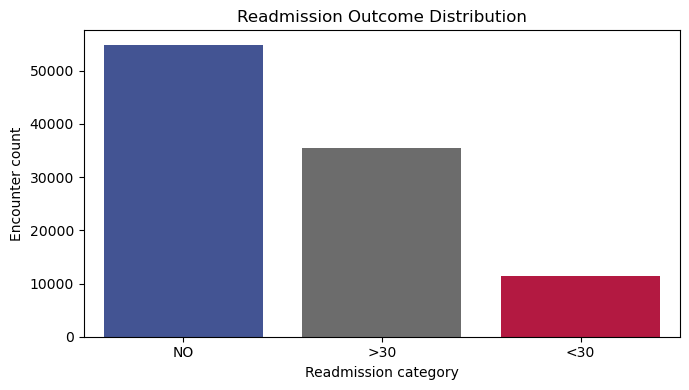

In [3]:
print("Columns:")
print(df_raw.columns.tolist())

print()
print("Readmission target distribution:")
readmission_counts = df_raw["readmitted"].value_counts()
readmission_order = ["NO", ">30", "<30"]
readmission_display = readmission_counts.reindex(readmission_order)
display(pd.DataFrame({
    "count": readmission_display,
    "percent": (readmission_display / len(df_raw) * 100).round(1)
}))

if HAS_PLOTTING:
    ax = readmission_display.plot(kind="bar", figsize=(7, 4), color=[SMU_BLUE, SMU_GRAY, SMU_RED])
    ax.set_title("Readmission Outcome Distribution")
    ax.set_xlabel("Readmission category")
    ax.set_ylabel("Encounter count")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Plot skipped because matplotlib is not installed.")


## 4. Cleaning and Feature Engineering
- Replace `?` with missing values.
- Use `IDS_mapping.csv` to translate administrative IDs into readable admission/discharge/source descriptions, then use grouped business categories instead of treating raw ID codes as ordinal numeric predictors.
- Remove discharge encounters that are not appropriate for a routine readmission-prevention decision, including hospice and expired dispositions.
- Keep `encounter_id` and `patient_nbr` for audit, worklists, and patient-level splitting, but exclude them from model features.
- Drop fields with excessive missingness (`weight`, `payer_code`) and near-zero-variance medication fields.
- Remove invalid gender rows.
- Encode age as an ordinal decade while also keeping the original age bracket for stakeholder display.
- Map medication activity to ordered values.
- Convert ICD-9 diagnosis codes into broader clinical chapters.
- Add decision-relevant features for prior utilization, medication activity, and discharge/admission context.

Binary target:

- `1` = readmitted within 30 days (`<30`)
- `0` = not readmitted within 30 days (`NO` or `>30`)

This target aligns directly with the business problem of identifying patients who may need enhanced transitional-care support.


In [4]:
def load_id_mappings(path):
    """Parse the UCI ID-mapping CSV, which stacks several small lookup tables in one file.

    Each section starts with a header row like ``admission_type_id,description`` and is
    followed by ``id, description`` rows until a blank line or the next section header.

    Returns
    -------
    dict[str, dict[int, str]]
        e.g. ``{"admission_type_id": {1: "Emergency", 2: "Urgent", ...}, ...}``
        Used below to turn opaque numeric codes into readable, stakeholder-facing labels.
    """
    mappings = {}
    current_section = None

    with open(path, newline="") as f:
        for row in csv.reader(f):
            if not row or not row[0].strip():
                continue

            first = row[0].strip()
            if first.endswith("_id"):
                current_section = first
                mappings[current_section] = {}
                continue

            if current_section is None:
                continue

            try:
                key = int(float(first))
            except ValueError:
                continue

            description = row[1].strip() if len(row) > 1 and row[1].strip() else "Unknown/not available"
            mappings[current_section][key] = description

    return mappings


ID_MAPPINGS = load_id_mappings(MAPPING_PATH)
for mapping_name, mapping_values in ID_MAPPINGS.items():
    print(f"{mapping_name}: {len(mapping_values)} mapped values")


def icd_chapter(code):
    """Collapse a raw ICD-9 diagnosis code into one of 19 broad clinical chapters.

    Individual ICD-9 codes are too sparse and high-cardinality to use directly as model
    features (thousands of distinct codes, many seen only once). Grouping into chapters
    (e.g. "Circulatory system", "Endocrine/metabolic") keeps the clinical signal that
    matters for readmission risk while giving the model enough examples per category to
    learn from. V- and E-codes (supplemental/external-cause codes) are mapped to their own
    chapters (18, 19); anything unparsable returns NaN and is treated as missing downstream.
    """
    if pd.isna(code):
        return np.nan

    code = str(code).strip()
    if code.startswith("V"):
        return 18
    if code.startswith("E"):
        return 19

    try:
        num = float(code)
    except ValueError:
        return np.nan

    if num < 140: return 1    # Infectious and parasitic diseases
    if num < 240: return 2    # Neoplasms
    if num < 280: return 3    # Endocrine, nutritional, metabolic, immunity
    if num < 290: return 4    # Blood diseases
    if num < 320: return 5    # Mental disorders
    if num < 390: return 6    # Nervous system and sense organs
    if num < 460: return 7    # Circulatory system
    if num < 520: return 8    # Respiratory system
    if num < 580: return 9    # Digestive system
    if num < 630: return 10   # Genitourinary system
    if num < 680: return 11   # Pregnancy/childbirth
    if num < 710: return 12   # Skin and subcutaneous tissue
    if num < 740: return 13   # Musculoskeletal system
    if num < 760: return 14   # Congenital anomalies
    if num < 780: return 15   # Perinatal period
    if num < 800: return 16   # Symptoms and ill-defined conditions
    if num < 1000: return 17  # Injury and poisoning
    return np.nan


def discharge_group(disposition_id):
    """Roll the ~30 raw discharge-disposition codes up into a small set of business-readable
    groups (e.g. "Home", "Skilled nursing facility"). This is the field a care manager would
    actually look at when deciding how complex a patient's post-discharge situation is."""
    groups = {
        1: "Home",
        6: "Home health",
        2: "Short-term hospital transfer",
        3: "Skilled nursing facility",
        4: "Intermediate care facility",
        5: "Other inpatient facility",
        7: "Left AMA",
        8: "Home IV provider",
        12: "Expected outpatient return",
        15: "Swing bed",
        16: "Outpatient referral",
        17: "Outpatient return",
        22: "Rehab facility",
        23: "Long-term care hospital",
        24: "Medicaid nursing facility",
        27: "Federal health care facility",
        28: "Psychiatric hospital",
        29: "Critical access hospital",
        30: "Other health care institution",
    }
    return groups.get(disposition_id, "Other/unknown")


def admission_type_group(admission_type_id):
    """Simplify the raw admission-type code into a business-readable label
    (e.g. "Emergency" vs. "Elective"), used for both display and modeling."""
    groups = {
        1: "Emergency",
        2: "Urgent",
        3: "Elective",
        4: "Newborn",
        5: "Not available",
        6: "Null",
        7: "Trauma center",
        8: "Not mapped",
    }
    return groups.get(admission_type_id, "Other/unknown")


def admission_source_group(source_id):
    """Bucket the raw admission-source code into a small number of business-meaningful
    categories (ER, referral, transfer, birth, unknown/other) rather than modeling dozens of
    granular source codes individually."""
    if source_id == 7:
        return "Emergency room"
    if source_id in [1, 2, 3]:
        return "Referral"
    if source_id in [4, 5, 6, 10, 18, 19, 22, 25, 26]:
        return "Transfer/continuing care"
    if source_id in [9, 15, 17, 20, 21]:
        return "Unknown/not available"
    if source_id in [11, 12, 13, 14, 23, 24]:
        return "Birth/newborn"
    return "Other"


def clean_diabetes_data(df, id_mappings):
    """Clean the raw UCI encounter table and engineer the features the model will use.

    This is the single place where every cleaning/feature-engineering *decision* for the
    project lives, so the rationale is documented right next to the code that implements it:

    1. Replace the dataset's ``"?"`` placeholder with a real missing value (``NaN``) so
       pandas/scikit-learn handle it correctly instead of treating it as a valid category.
    2. Drop hospice and expired discharge dispositions. A patient who died or entered
       hospice cannot benefit from a *readmission-prevention* intervention, so keeping them
       in the training population would teach the model on encounters outside the actual
       business decision.
    3. Map administrative ID codes (admission type/source, discharge disposition) to
       readable, grouped categories instead of using raw integer codes, which have no
       meaningful numeric order.
    4. Drop invalid/unknown gender rows (a small number of encounters) so the fairness
       checks in Section 12 compare only well-defined groups.
    5. Drop ``weight`` and ``payer_code`` (extremely high missingness) and any medication
       column where >99.9% of patients share the same value (near-zero variance, so the
       column can't meaningfully separate readmitted from non-readmitted patients).
    6. Keep ``encounter_id`` and ``patient_nbr`` for audit trails, worklists, and the
       patient-grouped train/test split, but exclude them from the model's feature matrix
       later (Section 7) so the model can't use them as spurious identifiers.
    7. Encode age as an ordinal decade and medication activity as an ordered scale
       (No < Steady < Down < Up), and group ICD-9 diagnosis codes into clinical chapters
       (see ``icd_chapter``).
    8. Engineer a handful of utilization/intensity features (prior visits, active
       medication count, tests/medications per day) that are common readmission-risk
       signals in the clinical literature.

    Returns
    -------
    (pandas.DataFrame, dict)
        The cleaned/engineered dataframe, and a small report dict used to print/display a
        summary of what was removed or dropped and why.
    """
    df = df.copy()
    starting_rows = len(df)
    df = df.replace("?", np.nan)

    missing_before = df.isna().mean().sort_values(ascending=False)

    # These encounters do not match the operational question of preventing a routine 30-day readmission.
    excluded_dispositions = [11, 13, 14, 19, 20, 21]
    df = df[~df["discharge_disposition_id"].isin(excluded_dispositions)].copy()

    df["admission_type_description"] = df["admission_type_id"].map(id_mappings["admission_type_id"])
    df["discharge_disposition_description"] = df["discharge_disposition_id"].map(id_mappings["discharge_disposition_id"])
    df["admission_source_description"] = df["admission_source_id"].map(id_mappings["admission_source_id"])
    df["discharge_group"] = df["discharge_disposition_id"].apply(discharge_group)
    df["admission_type_group"] = df["admission_type_id"].apply(admission_type_group)
    df["admission_source_group"] = df["admission_source_id"].apply(admission_source_group)

    df = df[df["gender"] != "Unknown/Invalid"].copy()

    high_missing_cols = ["weight", "payer_code"]

    medication_candidates = [
        "metformin", "repaglinide", "nateglinide", "chlorpropamide",
        "glimepiride", "acetohexamide", "glipizide", "glyburide",
        "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
        "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton",
        "insulin", "glyburide-metformin", "glipizide-metformin",
        "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
    ]
    near_zero_med_cols = []
    med_variance_rows = []
    for col in medication_candidates:
        if col not in df.columns:
            continue
        shares = df[col].value_counts(normalize=True, dropna=False)
        top_value = shares.index[0]
        top_share = float(shares.iloc[0])
        med_variance_rows.append({"column": col, "most_common_value": top_value, "most_common_share": top_share})
        if top_share >= 0.999:
            near_zero_med_cols.append(col)

    # Keep IDs for audit/worklists/splitting; do not use them as model predictors later.
    drop_cols = high_missing_cols + near_zero_med_cols + [
        "admission_type_id", "discharge_disposition_id", "admission_source_id"
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    for col in ["race", "medical_specialty", "max_glu_serum", "A1Cresult"]:
        if col in df.columns:
            df[col] = df[col].fillna("Unknown")

    age_map = {
        "[0-10)": 0, "[10-20)": 1, "[20-30)": 2, "[30-40)": 3,
        "[40-50)": 4, "[50-60)": 5, "[60-70)": 6,
        "[70-80)": 7, "[80-90)": 8, "[90-100)": 9,
    }
    df["age_ordinal"] = df["age"].map(age_map)

    med_cols = [col for col in medication_candidates if col in df.columns]
    med_map = {"No": 0, "Steady": 1, "Down": 2, "Up": 3}
    for col in med_cols:
        df[col] = df[col].map(med_map)

    active_med_cols = [col for col in med_cols if col in df.columns]
    df["num_active_diabetes_meds"] = (df[active_med_cols].fillna(0) > 0).sum(axis=1)
    df["medication_change_flag"] = (df["change"] == "Ch").astype(int)
    df["total_prior_visits"] = df[["number_outpatient", "number_emergency", "number_inpatient"]].sum(axis=1)
    df["had_prior_utilization"] = (df["total_prior_visits"] > 0).astype(int)
    df["tests_per_day"] = df["num_lab_procedures"] / df["time_in_hospital"].clip(lower=1)
    df["medications_per_day"] = df["num_medications"] / df["time_in_hospital"].clip(lower=1)

    for diag_col in ["diag_1", "diag_2", "diag_3"]:
        df[f"{diag_col}_chapter"] = df[diag_col].apply(icd_chapter)
        df = df.drop(columns=[diag_col])

    df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

    cleaning_report = {
        "starting_rows": starting_rows,
        "ending_rows": len(df),
        "rows_removed_for_hospice_expired_or_invalid_gender": starting_rows - len(df),
        "dropped_high_missing_cols": high_missing_cols,
        "dropped_near_zero_medication_cols": near_zero_med_cols,
        "top_missing_before_cleaning": missing_before[missing_before > 0].head(10),
        "medication_variance_review": pd.DataFrame(med_variance_rows).sort_values("most_common_share", ascending=False),
    }

    return df, cleaning_report


df, cleaning_report = clean_diabetes_data(df_raw, ID_MAPPINGS)
print("Cleaned shape:", df.shape)
print("Rows removed:", cleaning_report["rows_removed_for_hospice_expired_or_invalid_gender"])
print("Dropped high-missing columns:", cleaning_report["dropped_high_missing_cols"])
print("Dropped near-zero-variance medication columns:", cleaning_report["dropped_near_zero_medication_cols"])

display(cleaning_report["top_missing_before_cleaning"].to_frame("missing_percent_before_cleaning").assign(
    missing_percent_before_cleaning=lambda x: (x["missing_percent_before_cleaning"] * 100).round(1)
))
display(cleaning_report["medication_variance_review"].head(12).round(4))
display(df.head())


admission_type_id: 8 mapped values
discharge_disposition_id: 30 mapped values
admission_source_id: 25 mapped values
Cleaned shape: (99340, 47)
Rows removed: 2426
Dropped high-missing columns: ['weight', 'payer_code']
Dropped near-zero-variance medication columns: ['chlorpropamide', 'acetohexamide', 'tolbutamide', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


,missing_percent_before_cleaning
weight,96.9
max_glu_serum,94.7
A1Cresult,83.3
medical_specialty,49.1
payer_code,39.6
race,2.2
diag_3,1.4
diag_2,0.4
diag_1,0.0


,column,most_common_value,most_common_share
16,citoglipton,No,1.0000
15,examide,No,1.0000
22,metformin-pioglitazone,No,1.0000
20,glimepiride-pioglitazone,No,1.0000
5,acetohexamide,No,1.0000
21,metformin-rosiglitazone,No,1.0000
13,troglitazone,No,1.0000
19,glipizide-metformin,No,0.9999
8,tolbutamide,No,0.9998
12,miglitol,No,0.9996


,encounter_id,patient_nbr,race,gender,age,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,num_active_diabetes_meds,medication_change_flag,total_prior_visits,had_prior_utilization,tests_per_day,medications_per_day,diag_1_chapter,diag_2_chapter,diag_3_chapter,readmitted_30
0,2278392,8222157,Caucasian,Female,[0-10),1,Pediatrics-Endocrinology,41,0,1,...,0,0,0,0,41.000000,1.0,3.0,NaN,NaN,0
1,149190,55629189,Caucasian,Female,[10-20),3,Unknown,59,0,18,...,1,1,0,0,19.666667,6.0,3.0,3.0,3.0,0
2,64410,86047875,AfricanAmerican,Female,[20-30),2,Unknown,11,5,13,...,1,0,3,1,5.500000,6.5,11.0,3.0,18.0,0
3,500364,82442376,Caucasian,Male,[30-40),2,Unknown,44,1,16,...,1,1,0,0,22.000000,8.0,1.0,3.0,7.0,0
4,16680,42519267,Caucasian,Male,[40-50),1,Unknown,51,0,8,...,2,1,0,0,51.000000,8.0,2.0,2.0,3.0,0


Readmission target distribution:


,count,percent
readmitted_30,,
0,88026,88.6
1,11314,11.4


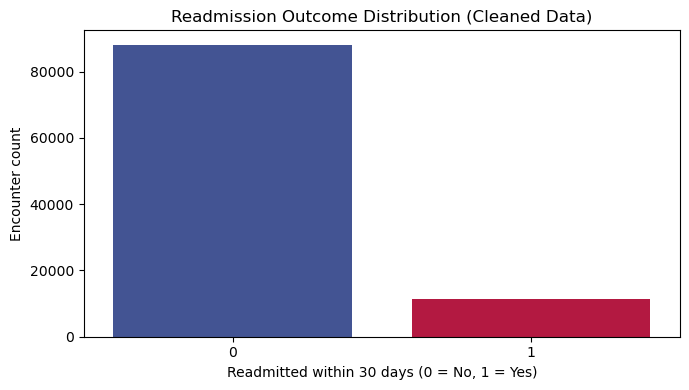

In [5]:
print("Readmission target distribution:")
readmission_counts = df["readmitted_30"].value_counts().reindex([0, 1])
display(pd.DataFrame({
    "count": readmission_counts,
    "percent": (readmission_counts / len(df) * 100).round(1)
}))

if HAS_PLOTTING:
    ax = readmission_counts.plot(kind="bar", figsize=(7, 4), color=[SMU_BLUE, SMU_RED])
    ax.set_title("Readmission Outcome Distribution (Cleaned Data)")
    ax.set_xlabel("Readmitted within 30 days (0 = No, 1 = Yes)")
    ax.set_ylabel("Encounter count")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Plot skipped because matplotlib is not installed.")


## 5. EDA for the Business Problem

The EDA focuses on whether the dataset supports the stakeholder decision: identifying high-risk discharge encounters and understanding which patient characteristics may create demand for transitional-care resources.

The most useful charts for this project are the ones that explain the decision problem:

- Is the target imbalanced enough that accuracy is a weak KPI?
- Do prior utilization, length of stay, medication burden, age, and discharge/admission context show different readmission patterns?
- Which patterns help justify a risk-ranked worklist, capacity planning, and care-management triage?


,label,count,percent
0,Not readmitted within 30 days,88026,88.6
1,Readmitted within 30 days,11314,11.4


,encounters,avg_time_in_hospital,avg_prior_inpatient,avg_prior_emergency,avg_prior_outpatient,avg_total_prior_visits,avg_num_medications
readmitted_30,,,,,,,
0,88026,4.33,0.55,0.18,0.36,1.09,15.86
1,11314,4.77,1.22,0.36,0.44,2.02,16.91


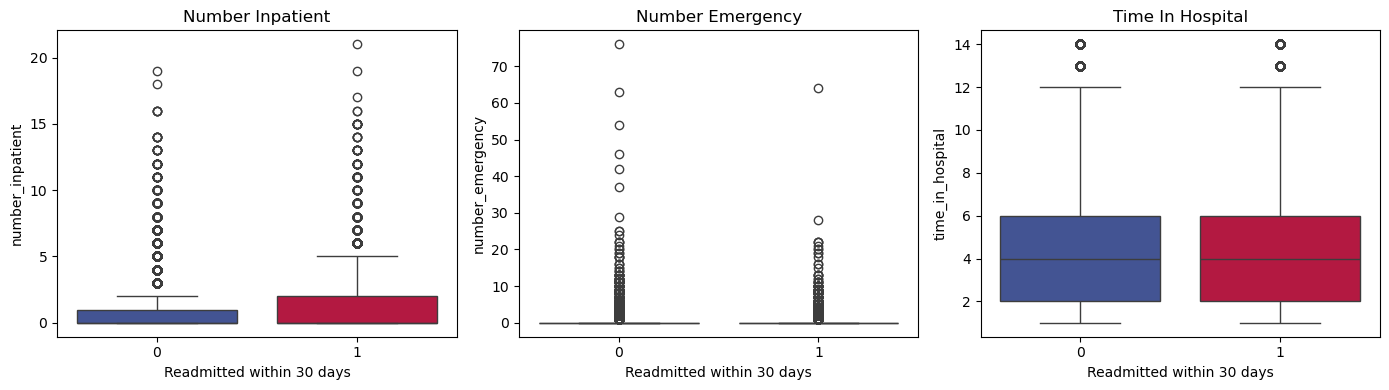

In [6]:
target_summary = df["readmitted_30"].value_counts().sort_index()
display(pd.DataFrame({
    "label": ["Not readmitted within 30 days", "Readmitted within 30 days"],
    "count": target_summary.values,
    "percent": (target_summary.values / len(df) * 100).round(1),
}))

eda_summary = df.groupby("readmitted_30").agg(
    encounters=("readmitted_30", "size"),
    avg_time_in_hospital=("time_in_hospital", "mean"),
    avg_prior_inpatient=("number_inpatient", "mean"),
    avg_prior_emergency=("number_emergency", "mean"),
    avg_prior_outpatient=("number_outpatient", "mean"),
    avg_total_prior_visits=("total_prior_visits", "mean"),
    avg_num_medications=("num_medications", "mean"),
    avg_active_diabetes_meds=("num_active_diabetes_meds", "mean"),
).round(2)
display(eda_summary)

missing_plot = cleaning_report["top_missing_before_cleaning"].copy().mul(100).round(1)
missing_plot = missing_plot[missing_plot > 0].sort_values(ascending=True)

if HAS_PLOTTING and len(missing_plot):
    ax = missing_plot.plot(kind="barh", figsize=(7, 4), color=SMU_GRAY)
    ax.set_title("Highest Missingness Before Cleaning")
    ax.set_xlabel("Missing values (%)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Missingness plot skipped because matplotlib is not installed or no missing values were found.")

eda_plot_df = df.copy()
eda_plot_df["prior_inpatient_group"] = pd.cut(
    eda_plot_df["number_inpatient"],
    bins=[-0.1, 0, 1, 2, 4, np.inf],
    labels=["0", "1", "2", "3-4", "5+"],
)
eda_plot_df["total_prior_visits_group"] = pd.cut(
    eda_plot_df["total_prior_visits"],
    bins=[-0.1, 0, 1, 2, 4, np.inf],
    labels=["0", "1", "2", "3-4", "5+"],
)
eda_plot_df["med_burden_group"] = pd.cut(
    eda_plot_df["num_medications"],
    bins=[-0.1, 10, 20, 30, np.inf],
    labels=["0-10", "11-20", "21-30", "31+"],
)


def readmission_rate_table(data, column, min_count=250, top_n=None):
    table = data.groupby(column, observed=False).agg(
        encounters=("readmitted_30", "size"),
        readmission_rate=("readmitted_30", "mean"),
    )
    table = table[table["encounters"] >= min_count].copy()
    table["readmission_rate"] = (table["readmission_rate"] * 100).round(1)
    table["population_share"] = (table["encounters"] / len(data) * 100).round(1)
    if top_n:
        table = table.sort_values("encounters", ascending=False).head(top_n)
    return table.sort_values("readmission_rate", ascending=False)

age_rate = readmission_rate_table(eda_plot_df, "age", min_count=100)
prior_rate = readmission_rate_table(eda_plot_df, "total_prior_visits_group", min_count=100)
med_rate = readmission_rate_table(eda_plot_df, "med_burden_group", min_count=100)
discharge_rate = readmission_rate_table(eda_plot_df, "discharge_group", min_count=500, top_n=8)
admission_source_rate = readmission_rate_table(eda_plot_df, "admission_source_group", min_count=500)
a1c_rate = readmission_rate_table(eda_plot_df, "A1Cresult", min_count=500)

print("Readmission rate by age bracket:")
display(age_rate)
print("Readmission rate by prior utilization group:")
display(prior_rate)
print("Readmission rate by discharge destination group:")
display(discharge_rate)
print("Readmission rate by A1C result:")
display(a1c_rate)

if HAS_PLOTTING:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    age_rate.sort_index()["readmission_rate"].plot(kind="bar", ax=axes[0, 0], color=SMU_BLUE)
    axes[0, 0].set_title("30-Day Readmission Rate by Age")
    axes[0, 0].set_xlabel("Age bracket")
    axes[0, 0].set_ylabel("Readmission rate (%)")
    axes[0, 0].tick_params(axis="x", rotation=45)

    prior_rate.sort_index()["readmission_rate"].plot(kind="bar", ax=axes[0, 1], color=SMU_RED)
    axes[0, 1].set_title("Readmission Rate by Prior Utilization")
    axes[0, 1].set_xlabel("Prior outpatient + ER + inpatient visits")
    axes[0, 1].set_ylabel("Readmission rate (%)")
    axes[0, 1].tick_params(axis="x", rotation=0)

    med_rate.sort_index()["readmission_rate"].plot(kind="bar", ax=axes[1, 0], color=SMU_GRAY)
    axes[1, 0].set_title("Readmission Rate by Medication Burden")
    axes[1, 0].set_xlabel("Number of medications")
    axes[1, 0].set_ylabel("Readmission rate (%)")
    axes[1, 0].tick_params(axis="x", rotation=0)

    discharge_rate.sort_values("readmission_rate")["readmission_rate"].plot(kind="barh", ax=axes[1, 1], color=SMU_BLUE)
    axes[1, 1].set_title("Readmission Rate by Discharge Setting")
    axes[1, 1].set_xlabel("Readmission rate (%)")
    axes[1, 1].set_ylabel("")

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    numeric_features_to_compare = ["number_inpatient", "number_emergency", "time_in_hospital"]
    for ax, feature in zip(axes, numeric_features_to_compare):
        data_to_plot = [
            df.loc[df["readmitted_30"] == 0, feature].clip(upper=df[feature].quantile(0.99)),
            df.loc[df["readmitted_30"] == 1, feature].clip(upper=df[feature].quantile(0.99)),
        ]
        ax.boxplot(data_to_plot, tick_labels=["No", "Yes"], patch_artist=True)
        ax.set_title(feature.replace("_", " ").title())
        ax.set_xlabel("Readmitted within 30 days")
    plt.tight_layout()
    plt.show()
else:
    print("EDA plots skipped because matplotlib is not installed.")


### EDA Takeaways for the Decision Model

These EDA outputs support the project direction without overclaiming causality:

- The 30-day readmission outcome is imbalanced, so the model should be judged by ranking, PR-AUC, recall at capacity, precision at capacity, calibration, and cost/value rather than accuracy alone.
- Prior utilization, discharge setting, medication burden, and age are practical signals for care-management workload and triage planning.
- The charts justify a capacity-constrained worklist: the stakeholder does not need a generic prediction report; they need a ranked list and scenario calculator tied to available intervention slots.
- The EDA also explains why the notebook keeps clinical and operational features while excluding identifiers, excessive-missingness fields, and encounters outside the preventable-readmission decision population.



## 6. Decision Metrics, KPI, and Business Equation

This is an imbalanced classification problem, but the business decision is not simply "predict yes/no." A care-management leader has a fixed number of intervention slots and needs the model to rank the best patients for those slots.

**Primary operating KPI:** `recall at capacity`.

\[
\text{Recall at capacity} = \frac{\text{Actual 30-day readmissions captured in the top N ranked patients}}{\text{All actual 30-day readmissions}}
\]

This answers: *Of the patients who actually came back within 30 days, how many did our limited worklist catch?* In code, this is `capacity_metrics()` below.

**Supporting model metrics:**

- **Precision at capacity:** how many selected patients were truly readmitted within 30 days.
- **Lift over random selection:** how much better the ranked worklist is than selecting patients randomly.
- **Average precision / PR-AUC:** overall ranking quality for a rare positive class.
- **Brier score / calibration:** whether predicted probabilities are trustworthy enough for cost math.
- **ROC-AUC, F1, and accuracy:** useful diagnostics, but not the main decision metric.

**Tuning metric:** PR-AUC / average precision, used in Section 7h to tune the selected model's hyperparameters. This is easier to explain than a separate tuning metric and fits the project because 30-day readmission is imbalanced and the model is mainly used to rank patients by risk. The business interpretation still comes from the capacity metrics: precision, recall, lift, and net value for the top intervention worklist.

**Executive/business KPI:** estimated net value.

\[
\text{Expected net value} = (\sum \text{selected calibrated risk} \times \text{intervention effectiveness} \times \text{cost per readmission}) - (\text{patients targeted} \times \text{cost per intervention})
\]

This is implemented twice in code, for two different jobs, and both use the same equation:

- `expected_net_value_at_capacity()` (Section 7) &mdash; a fast, score-only version used inside the model-comparison loop, where only predicted probabilities are available.
- `estimate_intervention_value()` (Section 10) &mdash; the full version used for the scenario table, which also returns patients targeted, expected/observed readmissions, gross avoided cost, intervention cost, and break-even effectiveness.

**Break-even risk for one more patient:**

\[
\text{Break-even risk} = \frac{\text{cost per intervention}}{\text{intervention effectiveness} \times \text{cost per readmission}}
\]

Using the default assumptions in this notebook, the break-even risk is `300 / (0.10 * 15000) = 0.20`. Patients above that calibrated risk have positive expected value under the default scenario; patients below it may still be served for clinical or equity reasons, but the financial case is weaker.


In [7]:

decision_canvas = pd.DataFrame({
    "Project element": [
        "Stakeholder",
        "Decision",
        "Action options",
        "Primary operating KPI",
        "Hyperparameter tuning objective",
        "Executive KPI",
        "Model output",
        "Business constraint",
        "Default business equation",
        "RAG role",
        "Fine-tuned model role",
    ],
    "Working definition": [
        "Director of Care Management / Transitional Care Manager",
        "Which eligible diabetes discharges should receive enhanced post-discharge support?",
        "Routine discharge, follow-up call + appointment coordination, or intensive nurse/pharmacist review",
        f"Recall at capacity: capture as many true 30-day readmissions as possible in the top {DEFAULT_CAPACITY} intervention slots",
        "Use a small patient-grouped cross-validation search scored by PR-AUC, because the target is imbalanced and the model is used for risk ranking",
        "Estimated net value from avoided readmissions minus intervention cost",
        "Calibrated probability of readmission within 30 days plus risk tier and ranked worklist",
        "Limited staff capacity and intervention budget",
        "Net value = sum(selected risk) * effectiveness * readmission cost - selected patients * intervention cost",
        "Retrieve CMS/AHRQ guidance to connect risk patterns to evidence-informed discharge actions",
        "Compare a required fine-tuned readmission classifier against the tabular ML pipeline using the same capacity and cost metrics",
    ],
})

display(decision_canvas)


,Project element,Working definition
0,Stakeholder,Director of Care Management / Transitional Car...
1,Decision,Which eligible diabetes discharges should rece...
2,Action options,"Routine discharge, follow-up call + appointmen..."
3,Primary operating KPI,Recall at capacity: capture as many true 30-da...
4,Hyperparameter tuning objective,Maximize F2 (recall weighted 2x precision) und...
5,Executive KPI,Estimated net value from avoided readmissions ...
6,Model output,Calibrated probability of readmission within 3...
7,Business constraint,Limited staff capacity and intervention budget
8,Default business equation,Net value = sum(selected risk) * effectiveness...
9,RAG role,Retrieve CMS/AHRQ guidance to connect risk pat...


## 7. Modeling Pipeline

This section keeps the modeling workflow simple and business-facing:

1. Split the data by patient so the same patient cannot appear in both train and test.
2. Build one shared preprocessing pipeline.
3. Fit each candidate model in its own short section.
4. Compare all models in one clean metrics table.
5. Tune only the selected model family with a small grouped cross-validation search.

The main decision is still capacity-based: a care-management leader has a fixed number of intervention slots, so the most useful model is the one that creates the strongest high-risk worklist.

### 7a. Target, Features, and Patient-Level Split

In [ ]:
y = df["readmitted_30"]
groups = df["patient_nbr"]

identifier_columns = ["encounter_id", "patient_nbr"]
redundant_columns = [
    "age",
    "admission_type_description",
    "discharge_disposition_description",
    "admission_source_description",
]
feature_drop_columns = ["readmitted", "readmitted_30"] + identifier_columns + redundant_columns

X = df.drop(columns=[col for col in feature_drop_columns if col in df.columns])

# Patient-level split prevents leakage from repeat encounters for the same patient.
group_split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(group_split.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
train_groups = groups.iloc[train_idx]
test_groups = groups.iloc[test_idx]

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "encounters": [len(X_train), len(X_test)],
    "unique_patients": [train_groups.nunique(), test_groups.nunique()],
    "readmission_30_rate": [y_train.mean(), y_test.mean()],
})

overlap = set(train_groups).intersection(set(test_groups))
print("Patient overlap between train and test:", len(overlap))
display(split_summary.round(4))

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Excluded identifier columns:", identifier_columns)


### 7b. Shared Preprocessing

In [ ]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_encoder(sparse=True)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

# HistGradientBoosting needs dense input, so it gets the same preprocessing logic with dense one-hot output.
categorical_pipe_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_onehot_encoder(sparse=False)),
])

preprocessor_dense = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe_dense, categorical_features),
])


### 7c. Baseline Logistic Regression

In [ ]:
baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])


### 7d. Balanced Logistic Regression

In [ ]:
balanced_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])


### 7e. Balanced Random Forest

In [ ]:
random_forest_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=120,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])


### 7f. Gradient Boosting

In [ ]:
gradient_boosting_model = Pipeline(steps=[
    ("preprocess", preprocessor_dense),
    ("model", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.06,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    )),
])


### 7g. Clean Model Metrics Comparison

Accuracy is included for context, but it is not the decision metric. The most important columns are the capacity metrics: precision, recall, lift, and expected net value for the top `DEFAULT_CAPACITY` patients.

In [ ]:
def capacity_metrics(y_true, y_score, capacity):
    """Evaluate the top-N highest-risk patients as the care-management worklist."""
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_score = pd.Series(y_score).reset_index(drop=True)
    capacity = min(int(capacity), len(y_true))

    selected_idx = y_score.sort_values(ascending=False).head(capacity).index
    selected_actual = y_true.iloc[selected_idx]
    actual_total = y_true.sum()
    base_rate = y_true.mean()

    precision_at_capacity = selected_actual.mean() if capacity > 0 else 0
    recall_at_capacity = selected_actual.sum() / actual_total if actual_total else 0
    lift = precision_at_capacity / base_rate if base_rate else np.nan

    return {
        f"precision_at_{capacity}": precision_at_capacity,
        f"recall_at_{capacity}": recall_at_capacity,
        f"lift_at_{capacity}": lift,
        f"readmissions_captured_at_{capacity}": int(selected_actual.sum()),
    }


def expected_net_value_at_capacity(y_score, capacity, readmission_cost, intervention_cost, effectiveness):
    scores = pd.Series(y_score).sort_values(ascending=False).head(int(capacity))
    return scores.sum() * effectiveness * readmission_cost - len(scores) * intervention_cost


def evaluate_model(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    cap = capacity_metrics(y_test, proba, DEFAULT_CAPACITY)

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_at_0_50": precision_score(y_test, pred, zero_division=0),
        "recall_at_0_50": recall_score(y_test, pred, zero_division=0),
        "f1_at_0_50": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "avg_precision_pr_auc": average_precision_score(y_test, proba),
        "brier_score": brier_score_loss(y_test, proba),
        "expected_net_value_at_capacity": expected_net_value_at_capacity(
            proba,
            DEFAULT_CAPACITY,
            DEFAULT_READMISSION_COST,
            DEFAULT_INTERVENTION_COST,
            DEFAULT_EFFECTIVENESS,
        ),
    }
    row.update(cap)
    return row, pred, proba


models = {
    "Baseline Logistic Regression": baseline_model,
    "Balanced Logistic Regression": balanced_model,
    "Balanced Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model,
}

model_scores = {}
rows = []
for name, model in models.items():
    row, pred, proba = evaluate_model(name, model)
    rows.append(row)
    model_scores[name] = {"pred": pred, "proba": proba}

capacity_key = DEFAULT_CAPACITY
results_raw = pd.DataFrame(rows).set_index("model")
selection_order = results_raw.sort_values(
    [f"recall_at_{capacity_key}", "avg_precision_pr_auc", "brier_score"],
    ascending=[False, False, True],
)
results = selection_order.round(4)

comparison_display = selection_order.rename(columns={
    "accuracy": "Accuracy",
    "roc_auc": "ROC-AUC",
    "avg_precision_pr_auc": "PR-AUC",
    "brier_score": "Brier",
    f"precision_at_{capacity_key}": f"Precision@{capacity_key}",
    f"recall_at_{capacity_key}": f"Recall@{capacity_key}",
    f"lift_at_{capacity_key}": f"Lift@{capacity_key}",
    f"readmissions_captured_at_{capacity_key}": f"Readmissions Captured@{capacity_key}",
    "expected_net_value_at_capacity": f"Estimated Net Value@{capacity_key}",
})[[
    "Accuracy",
    "ROC-AUC",
    "PR-AUC",
    "Brier",
    f"Precision@{capacity_key}",
    f"Recall@{capacity_key}",
    f"Lift@{capacity_key}",
    f"Readmissions Captured@{capacity_key}",
    f"Estimated Net Value@{capacity_key}",
]]

display(comparison_display.round(4))

final_model_name = selection_order.index[0]
final_model = models[final_model_name]
y_pred = model_scores[final_model_name]["pred"]
y_proba = model_scores[final_model_name]["proba"]

print(f"Selected model family: {final_model_name}")
print(f"Selection rule: highest recall at top {DEFAULT_CAPACITY}, then PR-AUC, then lower Brier score.")


### 7h. Simple Tuning of the Selected Model

This keeps the tuning step small and understandable. The search only tunes the model family selected above, uses patient-grouped cross-validation, and scores candidates with PR-AUC because the readmission class is imbalanced and the model is used for ranking.

In [ ]:
TUNING_SCORE = "average_precision"

tuning_param_grids = {
    "Baseline Logistic Regression": {
        "model__C": [0.01, 0.1, 1.0, 10.0],
    },
    "Balanced Logistic Regression": {
        "model__C": [0.01, 0.1, 1.0, 10.0],
    },
    "Balanced Random Forest": {
        "model__n_estimators": [120, 200],
        "model__max_depth": [8, 12, None],
        "model__min_samples_leaf": [25, 50, 100],
    },
    "Gradient Boosting": {
        "model__learning_rate": [0.03, 0.06, 0.1],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__l2_regularization": [0.0, 1.0, 3.0],
    },
}

param_grid = tuning_param_grids[final_model_name]
grid_size = 1
for values in param_grid.values():
    grid_size *= len(values)

search = RandomizedSearchCV(
    estimator=final_model,
    param_distributions=param_grid,
    n_iter=min(6, grid_size),
    scoring=TUNING_SCORE,
    cv=GroupKFold(n_splits=3),
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
)
search.fit(X_train, y_train, groups=train_groups)

tuned_model = search.best_estimator_
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]

pre_tuning_capacity = capacity_metrics(y_test, y_proba, DEFAULT_CAPACITY)
tuned_capacity = capacity_metrics(y_test, tuned_proba, DEFAULT_CAPACITY)

tuning_results = pd.DataFrame({
    "Stage": ["Selected model", "Tuned selected model"],
    f"Precision@{DEFAULT_CAPACITY}": [
        pre_tuning_capacity[f"precision_at_{DEFAULT_CAPACITY}"],
        tuned_capacity[f"precision_at_{DEFAULT_CAPACITY}"],
    ],
    f"Recall@{DEFAULT_CAPACITY}": [
        pre_tuning_capacity[f"recall_at_{DEFAULT_CAPACITY}"],
        tuned_capacity[f"recall_at_{DEFAULT_CAPACITY}"],
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_proba),
        average_precision_score(y_test, tuned_proba),
    ],
    "Brier": [
        brier_score_loss(y_test, y_proba),
        brier_score_loss(y_test, tuned_proba),
    ],
})

display(tuning_results.round(4))
print(f"Tuned model family: {final_model_name}")
print("Best parameters:", search.best_params_)
print(f"Best grouped-CV PR-AUC: {search.best_score_:.4f}")

# Use the tuned model for calibration, scoring, explainability, and saved artifacts.
final_model = tuned_model
y_proba = tuned_proba
risk_for_operating_rule = pd.Series(y_proba, index=X_test.index)
selected_index = risk_for_operating_rule.sort_values(ascending=False).head(DEFAULT_CAPACITY).index
y_pred_capacity = pd.Series(0, index=X_test.index)
y_pred_capacity.loc[selected_index] = 1
y_pred = y_pred_capacity.loc[X_test.index].astype(int).values


### 7i. Probability Calibration for Cost Math

The cost model treats the **sum of selected predicted risks** as the expected number of readmissions. That requires reasonably calibrated probabilities. The model is selected by worklist performance, tuned with a small grouped PR-AUC search, and then calibrated before the dollar calculations are used downstream.

The operational prediction is capacity-based: the "positive" class below means **selected into the top-N intervention worklist**, not simply `probability >= 0.50`.


In [ ]:

calibrated_model = CalibratedClassifierCV(final_model, method="isotonic", cv=3)
calibrated_model.fit(X_train, y_train)

brier_before = brier_score_loss(y_test, y_proba)
y_proba = calibrated_model.predict_proba(X_test)[:, 1]   # calibrated risk used downstream
brier_after = brier_score_loss(y_test, y_proba)

risk_for_operating_rule = pd.Series(y_proba, index=X_test.index)
selected_index = risk_for_operating_rule.sort_values(ascending=False).head(DEFAULT_CAPACITY).index
y_pred_capacity = pd.Series(0, index=X_test.index)
y_pred_capacity.loc[selected_index] = 1
y_pred = y_pred_capacity.loc[X_test.index].astype(int).values

calibrated_capacity_metrics = capacity_metrics(y_test, y_proba, DEFAULT_CAPACITY)
calibrated_net_value = expected_net_value_at_capacity(
    y_proba,
    DEFAULT_CAPACITY,
    DEFAULT_READMISSION_COST,
    DEFAULT_INTERVENTION_COST,
    DEFAULT_EFFECTIVENESS,
)

print(f"Calibrated the selected model ({final_model_name}).")
print(f"Brier score before: {brier_before:.4f} -> after: {brier_after:.4f} (lower is better).")
print(f"Operating rule: select the top {DEFAULT_CAPACITY} patients by calibrated risk.")
print(f"Calibrated precision at {DEFAULT_CAPACITY}: {calibrated_capacity_metrics[f'precision_at_{DEFAULT_CAPACITY}']:.3f}")
print(f"Calibrated recall at {DEFAULT_CAPACITY}: {calibrated_capacity_metrics[f'recall_at_{DEFAULT_CAPACITY}']:.3f}")
print(f"Calibrated expected net value at capacity: ${calibrated_net_value:,.0f}")


In [ ]:

print(f"Classification report for the top-{DEFAULT_CAPACITY} capacity worklist:")
print(classification_report(y_test, y_pred, target_names=["Not selected", "Selected"], zero_division=0))

cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm, index=["Actual not <30", "Actual <30"], columns=["Not selected", "Selected"] ))

calibration_table = pd.DataFrame({"actual": y_test.values, "risk_score": y_proba})
calibration_table["risk_decile"] = pd.qcut(
    calibration_table["risk_score"], q=10, labels=False, duplicates="drop"
)
calibration_summary = calibration_table.groupby("risk_decile").agg(
    patients=("actual", "size"),
    avg_predicted_risk=("risk_score", "mean"),
    observed_readmission_rate=("actual", "mean"),
).reset_index()
display(calibration_summary.round(4))

if HAS_PLOTTING:
    ConfusionMatrixDisplay(cm, display_labels=["Not selected", "Selected"]).plot(cmap="Blues", colorbar=False)
    plt.title(f"Capacity Worklist Confusion Matrix - {final_model_name}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(calibration_summary["avg_predicted_risk"], calibration_summary["observed_readmission_rate"], marker="o")
    max_risk = calibration_summary["avg_predicted_risk"].max()
    plt.plot([0, max_risk], [0, max_risk], linestyle="--", color="black", linewidth=0.8)
    plt.title("Calibration Check by Risk Decile")
    plt.xlabel("Average predicted risk")
    plt.ylabel("Observed 30-day readmission rate")
    plt.tight_layout()
    plt.show()
else:
    print("Plots skipped because matplotlib is not installed.")


## 8. Threshold and Capacity Analysis

A care-management team will not act on every score. This section turns model probabilities into operational choices: threshold cutoffs, number of patients flagged, expected readmissions captured, and workload size.


In [ ]:
def evaluate_thresholds(y_true, y_score, thresholds=None):
    """Sweep a fixed probability threshold and report the resulting worklist size,
    precision, recall, and F1 at each cut point.

    This view answers a different operational question than ``capacity_metrics``: instead
    of fixing the number of intervention slots, it fixes the risk cutoff and lets the
    number of flagged patients float. Useful for showing the precision/recall trade-off
    curve to a stakeholder who thinks in terms of "risk score above X", not "top N patients".
    """
    if thresholds is None:
        thresholds = np.round(np.arange(0.05, 0.55, 0.05), 2)

    rows = []
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    total_actual = y_true.sum()

    for threshold in thresholds:
        pred = (y_score >= threshold).astype(int)
        flagged = pred.sum()
        rows.append({
            "threshold": threshold,
            "patients_flagged": int(flagged),
            "flagged_percent": flagged / len(y_true),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "actual_readmissions_captured": int(((pred == 1) & (y_true == 1)).sum()),
            "actual_readmissions_total": int(total_actual),
        })
    return pd.DataFrame(rows)


def evaluate_capacity_table(y_true, y_score, capacities=(100, 250, 500, 1000, 2000)):
    """Report precision/recall/lift at several staffing-capacity levels, using
    ``capacity_metrics`` from Section 7. This is the "how does the worklist perform if we
    can afford N intervention slots" view a care-management leader would actually plan
    around, as opposed to the threshold-based view above.
    """
    rows = []
    for capacity in capacities:
        metrics = capacity_metrics(y_true, y_score, capacity)
        actual_capacity = min(int(capacity), len(y_true))
        rows.append({
            "capacity": actual_capacity,
            "patients_selected": actual_capacity,
            "precision_at_capacity": metrics[f"precision_at_{actual_capacity}"],
            "recall_at_capacity": metrics[f"recall_at_{actual_capacity}"],
            "lift_over_random": metrics[f"lift_at_{actual_capacity}"],
            "actual_readmissions_captured": metrics[f"readmissions_captured_at_{actual_capacity}"],
        })
    return pd.DataFrame(rows)


threshold_table = evaluate_thresholds(y_test, y_proba)
capacity_table = evaluate_capacity_table(y_test, y_proba)

print("Threshold view")
display(threshold_table.round(4))
print("Capacity view")
display(capacity_table.round(4))

if HAS_PLOTTING:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(threshold_table["threshold"], threshold_table["precision"], marker="o", label="Precision")
    axes[0].plot(threshold_table["threshold"], threshold_table["recall"], marker="o", label="Recall")
    axes[0].plot(threshold_table["threshold"], threshold_table["f1"], marker="o", label="F1")
    axes[0].set_title("Model Tradeoffs by Risk Threshold")
    axes[0].set_xlabel("Risk threshold")
    axes[0].set_ylabel("Metric")
    axes[0].legend()

    axes[1].plot(capacity_table["capacity"], capacity_table["recall_at_capacity"], marker="o", label="Recall at capacity")
    axes[1].plot(capacity_table["capacity"], capacity_table["precision_at_capacity"], marker="o", label="Precision at capacity")
    axes[1].set_title("Care-Management Capacity Tradeoff")
    axes[1].set_xlabel("Available intervention slots")
    axes[1].set_ylabel("Metric")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Threshold/capacity plots skipped because matplotlib is not installed.")


## 9. Risk Scoring and Patient Prioritization

The model probability is converted into risk tiers and proposed support levels. This makes the output easier for care managers to use than a raw probability alone.


In [ ]:
scored = df.loc[X_test.index, identifier_columns + [
    "age", "race", "gender", "time_in_hospital", "number_inpatient",
    "number_emergency", "number_outpatient", "discharge_group"
]].copy()
scored["actual_readmitted_30"] = y_test.values
scored["risk_score"] = y_proba
scored["risk_rank"] = scored["risk_score"].rank(method="first", ascending=False).astype(int)

scored["risk_tier"] = pd.qcut(
    scored["risk_score"],
    q=[0, 0.50, 0.80, 1.0],
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)

support_level_map = {
    "Low": "Routine discharge support",
    "Medium": "Follow-up call + appointment coordination",
    "High": "Intensive nurse care management + medication review",
}
scored["recommended_support_level"] = scored["risk_tier"].astype(str).map(support_level_map)

tier_summary = scored.groupby("risk_tier", observed=True).agg(
    patients=("risk_score", "size"),
    avg_risk_score=("risk_score", "mean"),
    actual_readmission_rate=("actual_readmitted_30", "mean"),
    actual_readmissions=("actual_readmitted_30", "sum"),
).round(4)

display(tier_summary)
display(scored.sort_values("risk_score", ascending=False).head(10)[[
    "risk_rank", "encounter_id", "patient_nbr", "risk_score", "risk_tier", "recommended_support_level",
    "actual_readmitted_30", "age", "race", "gender", "time_in_hospital",
    "number_inpatient", "number_emergency", "number_outpatient", "discharge_group"
]])


## 10. Cost and Savings Scenario Analysis

This section connects model output to the assignment's cost/value requirement. The assumptions are intentionally adjustable because exact local cost and intervention-effectiveness data are unavailable.


In [ ]:
def estimate_intervention_value(
    scored_df,
    threshold=DEFAULT_THRESHOLD,
    capacity=None,
    readmission_cost=DEFAULT_READMISSION_COST,
    intervention_cost=DEFAULT_INTERVENTION_COST,
    intervention_effectiveness=DEFAULT_EFFECTIVENESS,
):
    """Full implementation of the Section 6 cost/value equation, for a chosen operating
    rule (a risk ``threshold``, an optional staffing ``capacity`` cap, or both together).

    This is the "scenario calculator" version of the equation implemented compactly in
    ``expected_net_value_at_capacity`` (Section 7) -- it is slower because it works from the
    full scored dataframe, but it also returns every intermediate quantity a stakeholder
    would want to see, not just the final net-value number.

    Equation term -> code:
        selected/eligible patients        -> `eligible` (risk >= threshold, then capped at capacity)
        patients targeted                 -> flagged_patients
        expected readmissions (no action) -> expected_readmissions = sum(selected risk)
        intervention effectiveness        -> intervention_effectiveness
        expected readmissions avoided     -> prevented_readmissions = expected_readmissions * effectiveness
        cost per readmission              -> readmission_cost
        gross avoided cost                -> gross_avoided_cost = prevented_readmissions * readmission_cost
        cost per intervention              -> intervention_cost
        total intervention cost           -> total_intervention_cost = flagged_patients * intervention_cost
        estimated net value               -> net_value = gross_avoided_cost - total_intervention_cost

    ``break_even_effectiveness`` answers a related question: holding the selected
    population fixed, how effective would the intervention need to be for its cost to
    exactly offset the avoided-readmission savings (net value = 0)?
    """
    eligible = scored_df[scored_df["risk_score"] >= threshold].sort_values("risk_score", ascending=False).copy()
    if capacity is not None:
        eligible = eligible.head(int(capacity))

    flagged_patients = len(eligible)
    expected_readmissions = eligible["risk_score"].sum()
    observed_readmissions = eligible["actual_readmitted_30"].sum() if "actual_readmitted_30" in eligible else np.nan
    prevented_readmissions = expected_readmissions * intervention_effectiveness
    gross_avoided_cost = prevented_readmissions * readmission_cost
    total_intervention_cost = flagged_patients * intervention_cost
    net_value = gross_avoided_cost - total_intervention_cost
    break_even_effectiveness = (
        total_intervention_cost / (expected_readmissions * readmission_cost)
        if expected_readmissions > 0 and readmission_cost > 0 else np.nan
    )

    return pd.Series({
        "threshold": threshold,
        "capacity": "No cap" if capacity is None else int(capacity),
        "patients_targeted": flagged_patients,
        "expected_readmissions_without_intervention": expected_readmissions,
        "observed_readmissions_in_selected_test_rows": observed_readmissions,
        "assumed_intervention_effectiveness": intervention_effectiveness,
        "expected_readmissions_avoided": prevented_readmissions,
        "gross_avoided_readmission_cost": gross_avoided_cost,
        "total_intervention_cost": total_intervention_cost,
        "estimated_net_value": net_value,
        "break_even_effectiveness": break_even_effectiveness,
    })


base_scenario = estimate_intervention_value(
    scored,
    threshold=DEFAULT_THRESHOLD,
    capacity=DEFAULT_CAPACITY,
    readmission_cost=DEFAULT_READMISSION_COST,
    intervention_cost=DEFAULT_INTERVENTION_COST,
    intervention_effectiveness=DEFAULT_EFFECTIVENESS,
)

display(base_scenario.to_frame("estimate"))


In [ ]:
scenario_rows = []
for threshold in [0.20, 0.25, 0.30, 0.35, 0.40]:
    for capacity in [250, 500, 1000, None]:
        scenario_rows.append(estimate_intervention_value(
            scored,
            threshold=threshold,
            capacity=capacity,
            readmission_cost=DEFAULT_READMISSION_COST,
            intervention_cost=DEFAULT_INTERVENTION_COST,
            intervention_effectiveness=DEFAULT_EFFECTIVENESS,
        ))

scenario_table = pd.DataFrame(scenario_rows)
scenario_table = scenario_table.sort_values("estimated_net_value", ascending=False)
display(scenario_table.round(2))

if HAS_PLOTTING:
    plt.figure(figsize=(9, 4))
    plot_data = scenario_table[scenario_table["capacity"].astype(str) != "No cap"].copy().head(10)
    plot_data = plot_data.sort_values("estimated_net_value")
    plot_data["scenario"] = plot_data["threshold"].astype(str) + " / cap " + plot_data["capacity"].astype(str)
    plt.barh(plot_data["scenario"], plot_data["estimated_net_value"], color=SMU_BLUE)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Top Scenario Estimates by Net Value")
    plt.xlabel("Estimated net value ($)")
    plt.ylabel("Threshold / capacity")
    plt.tight_layout()
    plt.show()
else:
    print("Scenario plot skipped because matplotlib is not installed.")


### 10b. Marginal Value and Break-Even (the proposal's core question)

The proposal asks: **at what capacity does serving one more patient stop being worth it?** That is a *marginal* question. A patient is worth an intervention while their calibrated risk clears the break-even risk = intervention cost ÷ (effectiveness × readmission cost). Below that risk, the expected saving no longer covers the intervention.

In [ ]:

readmission_cost = DEFAULT_READMISSION_COST
intervention_cost = DEFAULT_INTERVENTION_COST
effectiveness = DEFAULT_EFFECTIVENESS

be_risk = intervention_cost / (effectiveness * readmission_cost)
n_worth = int((scored["risk_score"] >= be_risk).sum())
print(f"Break-even risk: serve while calibrated risk >= {be_risk:.3f}")
print(f"Patients above break-even risk in the test set: {n_worth}")

ranked = scored.sort_values("risk_score", ascending=False).reset_index(drop=True)
caps = list(range(100, 4001, 100))
marg = pd.DataFrame({"capacity": caps})
marg["cumulative_net_value"] = [
    ranked.head(c)["risk_score"].sum() * effectiveness * readmission_cost - c * intervention_cost
    for c in caps
]
marg["marginal_net_per_100"] = marg["cumulative_net_value"].diff()
opt = marg.loc[marg["marginal_net_per_100"] < 0, "capacity"].min()

if pd.isna(opt):
    print("Marginal net value stays positive across the tested capacity range under these assumptions.")
else:
    print(f"Marginal net value turns negative near {opt} patients under these assumptions.")

display(marg[marg["capacity"].isin([100, 300, 500, 1000, 2000, 4000])].round(0))

if HAS_PLOTTING:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(marg["capacity"], marg["cumulative_net_value"] / 1000, color=SMU_BLUE)
    ax[0].axhline(0, color="black", lw=0.8)
    ax[0].set_title("Cumulative net value")
    ax[0].set_xlabel("Patients served by risk rank")
    ax[0].set_ylabel("Net value ($000s)")
    ax[1].plot(marg["capacity"], marg["marginal_net_per_100"] / 1000, color=SMU_RED)
    ax[1].axhline(0, color="black", lw=0.8)
    if pd.notna(opt):
        ax[1].axvline(opt, ls="--", color=SMU_GRAY)
    ax[1].set_title("Marginal net value per +100 patients")
    ax[1].set_xlabel("Patients served by risk rank")
    ax[1].set_ylabel("Marginal ($000s)")
    plt.tight_layout()
    plt.show()


## 11. Explainability for Stakeholders

A business-facing product should explain why patients or segments are flagged, while avoiding overclaiming clinical causality from an observational dataset.


In [ ]:
# Permutation importance works for ANY model, including gradient boosting (which has
# no coefficients). It measures how far PR-AUC drops when each feature is shuffled.
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_imp, y_imp = X_test.iloc[sample_idx], y_test.iloc[sample_idx]

perm = permutation_importance(final_model, X_imp, y_imp, scoring="average_precision",
                              n_repeats=5, random_state=RANDOM_STATE)
importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=False)
display(importance.head(15).round(5))

if HAS_PLOTTING:
    top = importance.head(12).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top["feature"], top["importance"], xerr=top["std"], color=SMU_BLUE)
    plt.title(f"Permutation Importance - {final_model_name} (drop in PR-AUC)")
    plt.xlabel("Mean importance"); plt.tight_layout(); plt.show()
else:
    print("Explanation plot skipped because matplotlib is not installed.")

### Stakeholder Interpretation

The final report and app should translate model drivers into care-management language. Examples:

- More prior inpatient visits may signal recent instability and higher likelihood of returning.
- More prior emergency visits may signal unmanaged urgent care needs.
- Discharge disposition can indicate complexity after leaving the hospital.
- More diagnoses may suggest comorbidity burden.
- Medication activity may suggest treatment changes or diabetes management needs.

These explanations should be framed as **decision-support signals**, not as definitive clinical reasons for readmission.


## 12. Fairness, Limitations, and Appropriate Use Checks

The assignment asks for limitations, cautions, and appropriate-use guidance in the deployed app. These checks help identify whether recall and false negatives differ across demographic groups.


In [ ]:
fairness_df = df.loc[X_test.index, ["race", "gender", "age"]].copy()
fairness_df["actual"] = y_test.values
fairness_df["predicted"] = y_pred
fairness_df["risk_score"] = y_proba

def group_metrics(data, group_col):
    rows = []
    for value, group in data.groupby(group_col, dropna=False):
        if len(group) < 50:
            continue
        group_pred = group["predicted"]
        group_actual = group["actual"]
        recall = recall_score(group_actual, group_pred, zero_division=0)
        rows.append({
            "group": value,
            "n": len(group),
            "actual_rate": group_actual.mean(),
            "avg_risk_score": group["risk_score"].mean(),
            "predicted_positive_rate": group_pred.mean(),
            "recall": recall,
            "false_negative_rate": 1 - recall,
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)

print("Fairness by race")
display(group_metrics(fairness_df, "race").round(4))

print("Fairness by gender")
display(group_metrics(fairness_df, "gender").round(4))

print("Fairness by age")
display(group_metrics(fairness_df, "age").round(4))


## 12b. Extension: Using All Three Readmission Levels (`<30`, `>30`, `NO`)

The raw outcome has three levels. The primary model collapses them to binary (`<30` vs. the rest) because the **decision, the KPI, and the HRRP penalty are all 30-day-specific**. But the `>30` level is not just noise — it is an intermediate state, and there are three principled ways to use it:

1. **Multiclass** — predict all three classes, then read off `P(<30)` for ranking. Tested below.
2. **Ordinal** — treat `NO < >30 < <30` as increasing readmission severity (ordinal logistic / `mord`), which respects the natural ordering the multiclass model ignores.
3. **Tier enrichment** — use the predicted `>30` class to justify the *middle* support tier (moderate follow-up) with an actual predicted category, instead of only a probability cut on the binary score. This maps cleanly onto the routine / enhanced / intensive tiers already in the notebook.

The check below asks the business question directly: **does modeling all three levels rank 30-day patients any better than the binary model?**

In [ ]:
# Reuse the SAME patient-grouped split so this is comparable and leak-free.
y3 = df["readmitted"].map({"NO": 0, ">30": 1, "<30": 2})   # ordinal severity
y3_train, y3_test = y3.iloc[train_idx], y3.iloc[test_idx]

multiclass_model = Pipeline(steps=[
    ("preprocess", preprocessor_dense),
    ("model", HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=31, random_state=RANDOM_STATE)),
])
multiclass_model.fit(X_train, y3_train)

proba3 = multiclass_model.predict_proba(X_test)
pred3 = multiclass_model.predict(X_test)
classes = list(multiclass_model.classes_)
p_lt30_from_multiclass = proba3[:, classes.index(2)]       # P(<30) from the 3-class model

print("Three-class classification report:")
print(classification_report(y3_test, pred3, target_names=["NO", ">30", "<30"], zero_division=0))
cm3 = confusion_matrix(y3_test, pred3)
display(pd.DataFrame(cm3, index=["Actual NO", "Actual >30", "Actual <30"],
                     columns=["Pred NO", "Pred >30", "Pred <30"]))

# Business test: does the 3-class model rank <30 risk better than the binary model?
binary_prauc = average_precision_score(y_test, y_proba)
multiclass_prauc = average_precision_score(y_test, p_lt30_from_multiclass)
print(f"PR-AUC for ranking <30 risk -- binary model: {binary_prauc:.4f} | "
      f"multiclass-derived P(<30): {multiclass_prauc:.4f}")

# Map the predicted 3-level class straight onto the three support tiers
class_to_tier = {"NO": "Routine discharge support",
                 ">30": "Follow-up call + appointment coordination",
                 "<30": "Intensive nurse care management + medication review"}
class_counts = pd.Series(pred3).map({0: "NO", 1: ">30", 2: "<30"}).value_counts()
display(class_counts.rename("patients").to_frame().assign(
    support_tier=lambda d: d.index.map(class_to_tier)))

### Interpretation and recommendation

- **Keep the binary `<30` model as the triage/cost engine.** The multiclass-derived `P(<30)` ranks 30-day risk about the same or slightly *worse* (see the PR-AUC line above), and it complicates the cost model, which only needs `P(<30)`. Nothing is gained for the core decision by predicting three classes.
- **But the `>30` class is genuinely useful.** It is far more predictable than `<30` (higher precision/recall in the report), so it gives an evidence-based way to populate the **middle "enhanced follow-up" tier** — patients likely to return eventually but not within 30 days. That is a real operational segment for lower-intensity outreach.
- **Why hard 3-class prediction looks weak on `<30`:** at `argmax`, the model almost never *labels* a patient `<30` because that class is rare and overlaps heavily with the others. That is expected, and it is exactly why this project is framed as **ranking under capacity**, not hard classification — reinforcing the whole approach.
- **If you want the ordering respected,** an ordinal model (`NO < >30 < <30`, e.g. `mord.LogisticAT`) is the cleaner formulation than plain multiclass and is a nice "we considered alternatives" point for the write-up.

**On predicting "stays":** if you mean *length of stay* (`time_in_hospital`), that is a separate **regression** problem on pre-discharge features and would support bed/capacity planning — but note that readmission status **cannot** be a predictor of the current stay, because it happens *after* discharge (using it would be temporal leakage). If instead you mean predicting who **"stays out"** (does not come back), that is simply the inverse of the readmission target you already model. Either framing is defensible; just keep the time ordering clean so no post-discharge information leaks into a pre-discharge prediction.

## 13. Recommendation From the Structured-Data Model

The recommended final project direction is a readmission-risk classification and resource-prioritization pipeline, expanded into the required RAG, fine-tuned-model, and deployment components:

1. Predict whether a diabetic patient is likely to be readmitted within 30 days.
2. Convert the probability into a risk score.
3. Rank patients for capacity-constrained intervention slots.
4. Assign patients into low, medium, and high-priority support tiers.
5. Estimate the cost/savings impact of intervening with high-risk patients.
6. Explain the top factors driving the model's risk predictions.
7. Evaluate fairness across demographic groups.

This approach connects the model directly to a hospital decision: how to allocate limited discharge-support resources. The current model should be treated as a prototype because the UCI dataset is historical, observational, and not linked to measured intervention outcomes.



## 14. RAG Component Design

The assignment requires a RAG component using approved CMS/AHRQ-style documents about readmissions, discharge planning, care coordination, healthcare quality, or healthcare operations. The project folder already contains approved source PDFs in `pdfs/` and the deployed app folder mirrors them in `app/pdfs/`.

The class-code RAG notebooks are useful references for the pattern: load PDFs, chunk text, create embeddings, index vectors, retrieve the most relevant chunks, and generate a grounded response. For the final project, the app should keep the RAG role business-specific: it helps the care-management stakeholder decide *what discharge-planning actions to consider* for a risk segment or scenario. It should not act like an unrestricted medical chatbot.


In [ ]:

rag_build_plan = pd.DataFrame({
    "RAG requirement": [
        "Document collection",
        "Document loading and preprocessing",
        "Chunking strategy",
        "Embeddings",
        "Vector search / retrieval",
        "Prompt design",
        "Generated response",
        "Source grounding",
        "Evaluation and failure modes",
    ],
    "Project implementation plan": [
        "Use the approved CMS HRRP, AHRQ Re-Engineered Discharge Toolkit, and care-transition PDFs already stored in pdfs/ and app/pdfs/.",
        "Extract PDF text, preserve source file/title metadata, and remove page/header noise where feasible.",
        "Use overlapping chunks around 500-900 tokens so discharge-action recommendations keep enough context.",
        "Use a compact sentence-transformer embedding model, following the class-code RAG pattern but with production-safe wrappers.",
        "Index chunks with FAISS or use TF-IDF fallback when dense embedding dependencies are unavailable.",
        "Ask the model to answer as a care-management decision aid, cite retrieved sources, and state uncertainty.",
        "Return concise recommended considerations tied to the user's risk/capacity question.",
        "Display source title and snippet/citation for each answer.",
        "Test medication complexity, follow-up calls, equity, capacity limits, and inappropriate clinical advice requests.",
    ],
    "Notebook/app connection": [
        "Guidance tab corpus",
        "RAG preprocessing code in app/app.py",
        "Retriever quality",
        "Retriever index",
        "Question-answer workflow",
        "Business-facing answer behavior",
        "Stakeholder output",
        "Trust and auditability",
        "Limitations and governance",
    ],
})

display(rag_build_plan)


### 14b. Lightweight RAG Smoke Test Over the Collected PDFs

The deployed Gradio app contains the fuller RAG workflow, including dense embeddings/FAISS when dependencies are available. This notebook keeps the RAG demonstration simple and reproducible: it loads the approved PDFs in `pdfs/`, chunks the text, retrieves relevant chunks with TF-IDF, and shows source citations. That is enough to prove the corpus, preprocessing, retrieval, source grounding, and failure-mode checks are in place without making the notebook hard to run.

In [ ]:
try:
    from pypdf import PdfReader
    HAS_PYPDF = True
except ImportError:
    PdfReader = None
    HAS_PYPDF = False
    print("pypdf not installed; install app/requirements.txt to run the RAG smoke test.")

from sklearn.metrics.pairwise import cosine_similarity

PDF_DIR = PROJECT_DIR / "pdfs"
PDF_SOURCE_LABELS = {
    "HRRP_Formula.pdf": "CMS HRRP payment reduction formula",
    "goinghomeguide.pdf": "AHRQ Taking Care of Myself discharge guide",
    "dischargeprep.pdf": "AHRQ RED Discharge Preparation Workbook",
    "A Reengineered Hospital Discharge Program to Decrease Rehospitalization.pdf": "Project RED randomized trial",
}


def clean_rag_text(text):
    text = re.sub(r"\s+", " ", text or "").strip()
    return text.replace("(cid:0)", "-").replace("(cid:1)", "")


def chunk_rag_text(text, max_chars=950, overlap=160):
    text = clean_rag_text(text)
    chunks = []
    start = 0
    while start < len(text):
        end = min(start + max_chars, len(text))
        if end < len(text):
            sentence_break = max(text.rfind(". ", start, end), text.rfind("; ", start, end))
            if sentence_break > start + 350:
                end = sentence_break + 1
        chunk = text[start:end].strip()
        if len(chunk) > 120:
            chunks.append(chunk)
        if end >= len(text):
            break
        start = max(0, end - overlap)
    return chunks


def load_rag_chunks(pdf_dir=PDF_DIR):
    rows = []
    if not HAS_PYPDF:
        return pd.DataFrame(columns=["source", "label", "page", "text"])
    for pdf_path in sorted(Path(pdf_dir).glob("*.pdf")):
        reader = PdfReader(str(pdf_path))
        label = PDF_SOURCE_LABELS.get(pdf_path.name, pdf_path.stem)
        for page_number, page in enumerate(reader.pages, start=1):
            page_text = clean_rag_text(page.extract_text() or "")
            for chunk in chunk_rag_text(page_text):
                rows.append({
                    "source": pdf_path.name,
                    "label": label,
                    "page": page_number,
                    "text": chunk,
                })
    return pd.DataFrame(rows)


rag_chunks = load_rag_chunks()
if rag_chunks.empty:
    print(f"No RAG chunks were created. Check that PDFs exist in {PDF_DIR} and pypdf is installed.")
else:
    print(f"Loaded {rag_chunks['source'].nunique()} PDFs into {len(rag_chunks):,} chunks.")
    display(rag_chunks.groupby(["source", "label"]).size().rename("chunks").reset_index())


### 14c. Retrieve Source-Grounded Guidance

This retrieval step answers the same business question as the app: once the model identifies a high-risk patient or segment, what discharge-planning actions are supported by the collected guidance?

In [ ]:
if not rag_chunks.empty:
    rag_vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=1,
        max_features=15000,
    )
    rag_matrix = rag_vectorizer.fit_transform(rag_chunks["text"])

    def retrieve_rag_chunks(question, top_k=5):
        query_vector = rag_vectorizer.transform([question])
        scores = cosine_similarity(query_vector, rag_matrix).ravel()
        top_indices = scores.argsort()[::-1]

        results = []
        source_counts = {}
        for idx in top_indices:
            if scores[idx] <= 0:
                continue
            source = rag_chunks.iloc[idx]["source"]
            if source_counts.get(source, 0) >= 2:
                continue
            row = rag_chunks.iloc[idx].to_dict()
            row["score"] = float(scores[idx])
            results.append(row)
            source_counts[source] = source_counts.get(source, 0) + 1
            if len(results) >= top_k:
                break
        return pd.DataFrame(results)

    def build_rag_prompt(question, retrieved):
        context = "\n\n".join(
            f"[Source {i}: {row.label}, page {row.page}]\n{row.text}"
            for i, row in enumerate(retrieved.itertuples(), start=1)
        )
        return (
            "Answer for a hospital care-management leader using only the source excerpts. "
            "Cite source numbers and avoid clinical orders.\n\n"
            f"Source excerpts:\n{context}\n\nQuestion: {question}"
        )

    def rag_extractive_answer(question, top_k=5, min_score=0.02):
        retrieved = retrieve_rag_chunks(question, top_k=top_k)
        if retrieved.empty or retrieved["score"].max() < min_score:
            return "The collected PDFs do not provide enough source support to answer this question.", retrieved

        bullets = []
        for i, row in enumerate(retrieved.itertuples(), start=1):
            snippet = row.text[:240].rsplit(" ", 1)[0]
            bullets.append(f"- {snippet}... [Source {i}: {row.label}, p. {row.page}]")
        return "\n".join(bullets), retrieved

    demo_question = "What discharge support should high-risk diabetes patients receive?"
    demo_answer, demo_sources = rag_extractive_answer(demo_question)
    print("Question:", demo_question)
    print("\nRetrieved-source answer:")
    print(demo_answer)
    display(demo_sources[["label", "page", "score"]].round(3))
else:
    print("Skipping retrieval because no PDF chunks are available.")


### 14d. RAG Evaluation and Failure Modes

A useful RAG component needs two checks: relevant questions should retrieve sensible source material, and out-of-scope questions should not produce confident unsupported advice.

In [ ]:
if not rag_chunks.empty:
    rag_eval_questions = [
        "What support should high-risk discharges receive?",
        "What medication or appointment information should patients leave with?",
        "How does readmission risk connect to hospital payment exposure?",
        "What color should the hospital lobby be painted?",  # out-of-scope check
    ]

    eval_rows = []
    for question in rag_eval_questions:
        retrieved = retrieve_rag_chunks(question, top_k=3)
        top_score = float(retrieved["score"].max()) if not retrieved.empty else 0.0
        eval_rows.append({
            "question": question,
            "top_source": retrieved.iloc[0]["label"] if not retrieved.empty else "No source",
            "top_score": top_score,
            "behavior": "answer with citations" if top_score >= 0.02 else "abstain / not enough support",
        })

    display(pd.DataFrame(eval_rows).round(3))
else:
    print("Skipping RAG evaluation because no PDF chunks are available.")


## 15. Fine-Tuned Classifier Plan

The final instructions also require a fine-tuned readmission classifier. This notebook prepares the structured-data pipeline, a text-style fine-tuning training set, a held-out evaluation set, and a comparison helper. To close the final-project requirement inside this workspace, it also trains a local prompt-based text classifier on the generated examples and compares it against the tabular model using the same capacity, cost, calibration, and fairness metrics. The Colab transformer template remains available as an optional stronger extension.


In [ ]:
def make_finetuning_prompt(row):
    """Turn one structured encounter row into a natural-language prompt for the text
    classifier, so the same underlying features used by the tabular model (age, prior
    utilization, medications, discharge context) are also available to the fine-tuned
    model in a format it can read. Keeping the same underlying signal in both models makes
    the model-comparison in Section 15b an apples-to-apples test of *modeling approach*,
    not of which model happened to see better features.
    """
    return (
        "Classify whether this diabetes inpatient encounter is readmitted within 30 days. "
        f"Age: {row.get('age')}; race: {row.get('race')}; gender: {row.get('gender')}; "
        f"time in hospital: {row.get('time_in_hospital')}; prior inpatient visits: {row.get('number_inpatient')}; "
        f"prior emergency visits: {row.get('number_emergency')}; prior outpatient visits: {row.get('number_outpatient')}; "
        f"number of medications: {row.get('num_medications')}; number of diagnoses: {row.get('number_diagnoses')}; "
        f"A1C result: {row.get('A1Cresult')}; insulin: {row.get('insulin')}; "
        f"discharge group: {row.get('discharge_group')}; admission source: {row.get('admission_source_group')}."
    )


fine_tuning_frame = df.loc[X_train.index].sample(
    n=min(2000, len(X_train)), random_state=RANDOM_STATE
).copy()
fine_tuning_examples = pd.DataFrame({
    "text": fine_tuning_frame.apply(make_finetuning_prompt, axis=1),
    "label": fine_tuning_frame["readmitted_30"].map({0: "not_readmitted_within_30_days", 1: "readmitted_within_30_days"}),
})

display(fine_tuning_examples.head())
print("Fine-tuning scaffold examples:", len(fine_tuning_examples))



### 15b. Fine-Tuned Classifier Evaluation Scaffold

The fine-tuned model should be evaluated as a **business classifier**, not just as a course requirement. The goal is to answer: does the fine-tuned text classifier improve the care-management worklist compared with the calibrated tabular model?

Recommended training setup:

- Train on `fine_tuning_readmission_examples.jsonl`.
- Evaluate on the held-out patient-grouped test prompts created below.
- Save predictions as `fine_tuned_readmission_predictions.csv` with at least these columns: `actual_readmitted_30` and `fine_tuned_score`.
- Compare it using the same metrics as the structured-data model: PR-AUC, precision@capacity, recall@capacity, lift@capacity, Brier score, and estimated net value.

The fine-tuned model does **not** need to win. If it performs worse, the right data-science conclusion is to keep Gradient Boosting as the production triage engine and present the fine-tuned classifier as a required comparison model that is less suitable for this tabular resource-allocation decision.


In [ ]:

fine_tuning_eval_frame = df.loc[X_test.index].copy()
fine_tuning_eval_examples = pd.DataFrame({
    "encounter_id": fine_tuning_eval_frame["encounter_id"].values,
    "patient_nbr": fine_tuning_eval_frame["patient_nbr"].values,
    "text": fine_tuning_eval_frame.apply(make_finetuning_prompt, axis=1),
    "label": fine_tuning_eval_frame["readmitted_30"].map({
        0: "not_readmitted_within_30_days",
        1: "readmitted_within_30_days",
    }),
    "actual_readmitted_30": fine_tuning_eval_frame["readmitted_30"].values,
})

fine_tuning_files = pd.DataFrame({
    "file": [
        "fine_tuning_readmission_examples.jsonl",
        "fine_tuning_eval_examples.jsonl",
        "fine_tuned_readmission_predictions.csv",
    ],
    "purpose": [
        "Training examples for the fine-tuned classifier",
        "Held-out patient-grouped prompts for evaluation",
        "Predictions created by the local prompt classifier below; optional Colab transformer can also create this file",
    ],
    "status": [
        "Created by this notebook",
        "Created by this notebook",
        "Created by the local fine-tuned prompt classifier below",
    ],
})

display(fine_tuning_files)
display(fine_tuning_eval_examples.head())
print("Held-out fine-tuning eval examples:", len(fine_tuning_eval_examples))



#### Colab Training Template

Use the template below in a GPU runtime after uploading/copying the two JSONL files from `app/artifacts/`. It fine-tunes a compact text classifier and writes the prediction CSV that the next notebook cell knows how to evaluate.


In [ ]:

colab_training_template = """
# Colab GPU setup
!pip install -q transformers datasets accelerate scikit-learn pandas numpy

import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

TRAIN_JSONL = "/content/fine_tuning_readmission_examples.jsonl"
EVAL_JSONL = "/content/fine_tuning_eval_examples.jsonl"
MODEL_NAME = "distilbert-base-uncased"

label2id = {
    "not_readmitted_within_30_days": 0,
    "readmitted_within_30_days": 1,
}
id2label = {v: k for k, v in label2id.items()}

data = load_dataset("json", data_files={"train": TRAIN_JSONL, "eval": EVAL_JSONL})
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    tokens = tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)
    tokens["labels"] = [label2id[label] for label in batch["label"]]
    return tokens

tokenized = data.map(tokenize, batched=True)
keep_cols = ["input_ids", "attention_mask", "labels"]
tokenized = tokenized.remove_columns([c for c in tokenized["train"].column_names if c not in keep_cols])
tokenized.set_format("torch")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    label2id=label2id,
    id2label=id2label,
)

args = TrainingArguments(
    output_dir="/content/diabetes-ft-classifier",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["eval"],
    tokenizer=tokenizer,
)
trainer.train()

pred_output = trainer.predict(tokenized["eval"])
logits = pred_output.predictions
probabilities = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

eval_records = pd.read_json(EVAL_JSONL, lines=True)
predictions = eval_records[["encounter_id", "patient_nbr", "actual_readmitted_30"]].copy()
predictions["fine_tuned_score"] = probabilities
predictions["fine_tuned_label"] = (predictions["fine_tuned_score"] >= 0.50).astype(int)

print("PR-AUC:", average_precision_score(predictions["actual_readmitted_30"], predictions["fine_tuned_score"]))
print("ROC-AUC:", roc_auc_score(predictions["actual_readmitted_30"], predictions["fine_tuned_score"]))
print("Brier score:", brier_score_loss(predictions["actual_readmitted_30"], predictions["fine_tuned_score"]))

predictions.to_csv("/content/fine_tuned_readmission_predictions.csv", index=False)
trainer.save_model("/content/diabetes-ft-classifier/final")
tokenizer.save_pretrained("/content/diabetes-ft-classifier/final")
"""

print("Colab template stored in `colab_training_template`.")
print("First lines:")
print("\n".join(colab_training_template.strip().splitlines()[:28]))



#### Local Fine-Tuned Prompt Classifier

Because the transformer weights are not cached locally and this workspace has no guaranteed GPU download path, this section completes the required comparison with a lightweight text classifier trained on the generated readmission prompts. It is fine-tuned to this project's prompt format, saves predictions for the app, and uses the same business KPI table as the structured model.


In [ ]:
fine_tuning_train = fine_tuning_examples.dropna(subset=["text", "label"]).copy()
train_labels = fine_tuning_train["label"].map({
    "not_readmitted_within_30_days": 0,
    "readmitted_within_30_days": 1,
}).astype(int)

class_counts = train_labels.value_counts().sort_index()
if len(class_counts) < 2:
    raise ValueError("Fine-tuned classifier needs both readmitted and not-readmitted examples.")
if class_counts.min() < 2:
    raise ValueError("Fine-tuned classifier needs at least two examples in each class for calibration.")

calibration_cv = min(3, int(class_counts.min()))
print("Fine-tuning label counts:")
display(class_counts.rename(index={0: "not_readmitted_within_30_days", 1: "readmitted_within_30_days"}).to_frame("examples"))
print("Calibration folds:", calibration_cv)

fine_tuned_base_model = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=25_000,
        strip_accents="unicode",
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

fine_tuned_text_model = CalibratedClassifierCV(
    fine_tuned_base_model,
    method="sigmoid",
    cv=calibration_cv,
)
fine_tuned_text_model.fit(fine_tuning_train["text"], train_labels)
fine_tuned_scores = fine_tuned_text_model.predict_proba(fine_tuning_eval_examples["text"])[:, 1]

fine_tuned_predictions = fine_tuning_eval_examples[[
    "encounter_id",
    "patient_nbr",
    "actual_readmitted_30",
]].copy()
fine_tuned_predictions["fine_tuned_score"] = fine_tuned_scores
fine_tuned_predictions["fine_tuned_label"] = (fine_tuned_predictions["fine_tuned_score"] >= 0.50).astype(int)

ARTIFACT_DIR.mkdir(exist_ok=True)
fine_tuned_predictions.to_csv(FINE_TUNED_PREDICTION_PATH, index=False)
with open(FINE_TUNED_MODEL_PATH, "wb") as f:
    pickle.dump(fine_tuned_text_model, f)

print("Saved fine-tuned prompt classifier predictions:", FINE_TUNED_PREDICTION_PATH)
print("Saved calibrated fine-tuned prompt classifier model:", FINE_TUNED_MODEL_PATH)
display(fine_tuned_predictions.head())


In [ ]:

def evaluate_score_model(name, y_true, y_score, status="complete"):
    """Compute one row of the model-comparison table using the SAME metrics used
    everywhere else in the notebook (0.50-threshold diagnostics, ranking metrics, capacity
    metrics from Section 7, and the Section 6 net-value equation). Used to put the tabular
    pipeline and the fine-tuned text classifier on a single, comparable scorecard.
    """
    y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
    y_score = pd.Series(y_score).astype(float).reset_index(drop=True)
    y_pred_default = (y_score >= 0.50).astype(int)
    capacity = min(DEFAULT_CAPACITY, len(y_true))
    cap = capacity_metrics(y_true, y_score, capacity)
    return {
        "model": name,
        "status": status,
        "accuracy_at_0_50": accuracy_score(y_true, y_pred_default),
        "precision_at_0_50": precision_score(y_true, y_pred_default, zero_division=0),
        "recall_at_0_50": recall_score(y_true, y_pred_default, zero_division=0),
        "f1_at_0_50": f1_score(y_true, y_pred_default, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "avg_precision_pr_auc": average_precision_score(y_true, y_score),
        "brier_score": brier_score_loss(y_true, y_score),
        f"precision_at_{capacity}": cap[f"precision_at_{capacity}"],
        f"recall_at_{capacity}": cap[f"recall_at_{capacity}"],
        f"lift_at_{capacity}": cap[f"lift_at_{capacity}"],
        f"readmissions_captured_at_{capacity}": cap[f"readmissions_captured_at_{capacity}"],
        "expected_net_value_at_capacity": expected_net_value_at_capacity(
            y_score,
            capacity,
            DEFAULT_READMISSION_COST,
            DEFAULT_INTERVENTION_COST,
            DEFAULT_EFFECTIVENESS,
        ),
    }


def evaluate_fine_tuned_predictions(path=FINE_TUNED_PREDICTION_PATH):
    """Build the two-row comparison table (tuned/calibrated tabular model vs. fine-tuned
    text classifier). If the fine-tuned predictions file does not exist yet, returns a
    placeholder row marked "pending" instead of failing, so the notebook can still run
    top-to-bottom before that artifact has been produced.
    """
    tabular_row = evaluate_score_model(
        f"Tabular {final_model_name} (tuned + calibrated)",
        y_test,
        y_proba,
    )

    if not Path(path).exists():
        pending_row = {key: np.nan for key in tabular_row.keys()}
        pending_row.update({
            "model": "Fine-tuned text classifier",
            "status": f"pending - add predictions to {path.name}",
        })
        return pd.DataFrame([tabular_row, pending_row])

    predictions = pd.read_csv(path)
    required_cols = {"actual_readmitted_30", "fine_tuned_score"}
    missing_cols = required_cols.difference(predictions.columns)
    if missing_cols:
        raise ValueError(f"Missing required prediction columns: {sorted(missing_cols)}")

    fine_tuned_row = evaluate_score_model(
        "Fine-tuned prompt classifier",
        predictions["actual_readmitted_30"],
        predictions["fine_tuned_score"],
    )
    return pd.DataFrame([tabular_row, fine_tuned_row])


fine_tuned_comparison = evaluate_fine_tuned_predictions()
fine_tuned_comparison.to_csv(FINE_TUNED_COMPARISON_PATH, index=False)
display(fine_tuned_comparison.round(4))
print("Saved model comparison:", FINE_TUNED_COMPARISON_PATH)


## 16. Save Reusable Model and App Inputs

The final project must include a saved or reusable model. This cell saves the current scikit-learn pipeline and a small sample dataset that the Gradio prototype can use on Hugging Face Spaces.


In [ ]:
ARTIFACT_DIR.mkdir(exist_ok=True)

model_bundle = {
    "model": calibrated_model,        # calibrated pipeline used for scoring in the app
    "explain_model": final_model,     # uncalibrated (but tuned) pipeline used for explainability
    "model_name": final_model_name,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "feature_columns": X.columns.tolist(),
    "identifier_columns": identifier_columns,
    "target": "readmitted_30",
    "business_problem": "Prioritize eligible diabetes discharge encounters for transitional-care support.",
    "support_levels": support_level_map,
}

with open(ARTIFACT_DIR / "diabetes_readmission_pipeline.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

sample_for_app = X_test.copy().reset_index(drop=True)
sample_identifiers = df.loc[X_test.index, identifier_columns].reset_index(drop=True)
sample_for_app = pd.concat([sample_identifiers, sample_for_app], axis=1)
sample_for_app["actual_readmitted_30"] = y_test.reset_index(drop=True)
sample_for_app["risk_score"] = y_proba
sample_for_app["risk_tier"] = scored.reset_index(drop=True)["risk_tier"].astype(str)
sample_for_app["recommended_support_level"] = scored.reset_index(drop=True)["recommended_support_level"]
sample_for_app.sort_values("risk_score", ascending=False).head(500).to_csv(
    ARTIFACT_DIR / "sample_scored_patients.csv", index=False
)

fine_tuning_examples.to_json(
    ARTIFACT_DIR / "fine_tuning_readmission_examples.jsonl",
    orient="records",
    lines=True,
)

fine_tuning_eval_examples.to_json(
    ARTIFACT_DIR / "fine_tuning_eval_examples.jsonl",
    orient="records",
    lines=True,
)

model_summary = {
    "model_name": final_model_name,
    "intended_user": "Hospital care-management or transitional-care leader",
    "intended_decision": "Prioritize patients for post-discharge support under staff and budget constraints",
    "pre_tuning_model_metrics": results.loc[final_model_name].to_dict(),
    "selection_rule": f"Highest recall at top {DEFAULT_CAPACITY}, then PR-AUC, then lower Brier score",
    "hyperparameter_tuning": {
        "method": "Small RandomizedSearchCV with GroupKFold(3) on patient_nbr",
        "scoring_metric": "PR-AUC / average precision",
        "best_params": search.best_params_,
        "best_cv_score": float(search.best_score_),
    },
    "calibrated_brier_score": float(brier_after),
    "calibrated_expected_net_value_at_capacity": float(calibrated_net_value),
    "calibrated_capacity_metrics": {
        key: float(value) for key, value in calibrated_capacity_metrics.items()
    },
    "fine_tuning_evaluation_status": "complete - local prompt classifier trained, saved, and compared",
    "fine_tuned_model_type": "Calibrated TF-IDF prompt text classifier with class-weighted logistic regression",
    "fine_tuned_comparison": fine_tuned_comparison.round(4).to_dict(orient="records"),
    "default_cost_assumptions": {
        "readmission_cost": DEFAULT_READMISSION_COST,
        "intervention_cost": DEFAULT_INTERVENTION_COST,
        "intervention_effectiveness": DEFAULT_EFFECTIVENESS,
        "capacity": DEFAULT_CAPACITY,
        "threshold": DEFAULT_THRESHOLD,
    },
    "data_steps": [
        "Replaced '?' placeholders with missing values.",
        "Excluded expired and hospice discharge dispositions from the preventable-readmission decision population.",
        "Mapped administrative IDs to readable/grouped categories and removed raw ID codes from model features.",
        "Kept patient identifiers out of features and used patient-level group split to reduce leakage.",
        "Grouped ICD-9 diagnosis codes into broader clinical chapters.",
        "Dropped excessive-missingness and near-zero-variance fields.",
    ],
    "limitations": [
        "Prototype trained on historical public data, not locally validated hospital data.",
        "Predicted risk should support human review, not replace clinical judgment.",
        "Cost and intervention-effectiveness assumptions are scenario inputs, not measured financial outcomes.",
        "Fairness and calibration should be monitored before real deployment.",
        "A local prompt-based fine-tuned text classifier was trained and compared; a transformer/LoRA GPU run remains an optional extension if stronger LLM fine-tuning evidence is desired.",
    ],
}

with open(ARTIFACT_DIR / "model_summary.json", "w") as f:
    json.dump(model_summary, f, indent=2)

print("Saved:")
print(ARTIFACT_DIR / "diabetes_readmission_pipeline.pkl")
print(ARTIFACT_DIR / "sample_scored_patients.csv")
print(ARTIFACT_DIR / "fine_tuning_readmission_examples.jsonl")
print(ARTIFACT_DIR / "fine_tuning_eval_examples.jsonl")
print(FINE_TUNED_PREDICTION_PATH)
print(FINE_TUNED_MODEL_PATH)
print(FINE_TUNED_COMPARISON_PATH)
print(ARTIFACT_DIR / "model_summary.json")


In [ ]:

requirements_txt = """pandas>=2.0
numpy>=1.24
scikit-learn>=1.3
matplotlib>=3.7
seaborn>=0.12
# --- app / Hugging Face Space dependencies ---
gradio>=5.0
pypdf>=5.0
sentence-transformers>=2.7
faiss-cpu>=1.8
openai>=1.0
"""
requirements_path = APP_DIR / "requirements.txt" if APP_DIR.exists() else PROJECT_DIR / "requirements.txt"
requirements_path.write_text(requirements_txt)
print("Wrote", requirements_path)
print(requirements_txt)


## 17. Gradio / Hugging Face Space App Idea

**App name:** Transitional Care Triage Studio

**Audience:** Hospital Director of Care Management, transitional-care manager, quality-improvement leader, or finance partner.

**Primary app workflow:**

1. **Score Patients:** Upload eligible discharge encounters or use a sample. The app predicts 30-day readmission risk and assigns each patient to routine, enhanced, or intensive support.
2. **Plan Capacity:** Adjust risk threshold, staff capacity, intervention cost, cost per readmission, and expected intervention effectiveness. The app estimates targeted patients, expected readmissions avoided, intervention cost, gross savings, net value, and break-even effectiveness.
3. **Compare Models:** Compare baseline ML, class-balanced ML, Gradient Boosting, and the fine-tuned prompt classifier using the same business KPI table.
4. **Ask Guidance Questions:** Use a RAG tab grounded in CMS/AHRQ discharge-planning and readmission documents to answer questions such as “What interventions are appropriate for patients with medication complexity and prior utilization?”
5. **Explain and Govern:** Show top risk factors, fairness checks, limitations, appropriate-use language, and implementation cautions.

**Recommended Hugging Face Space structure:**

```text
app.py
requirements.txt
artifacts/diabetes_readmission_pipeline.pkl
artifacts/sample_scored_patients.csv
artifacts/model_summary.json
artifacts/fine_tuning_readmission_examples.jsonl
artifacts/fine_tuning_eval_examples.jsonl
artifacts/fine_tuned_readmission_predictions.csv
artifacts/fine_tuned_model_comparison.csv
pdfs/                  # CMS/AHRQ PDFs for the RAG component
README.md              # Space instructions and project summary
```

The app can launch with the saved scikit-learn pipeline, scenario planner, approved-document RAG pipeline, and fine-tuned prompt-classifier comparison.


In [ ]:
gradio_feature_plan = pd.DataFrame({
    "App section": [
        "Overview",
        "Score Patients",
        "Scenario Planner",
        "Model Comparison",
        "RAG Guidance",
        "Governance & Limits",
    ],
    "User question answered": [
        "What decision does this tool support?",
        "Which patients should be prioritized?",
        "What threshold/capacity plan creates the most value?",
        "Which model is most useful for this business decision?",
        "What discharge or care-transition actions are supported by CMS/AHRQ guidance?",
        "What should stakeholders avoid overclaiming?",
    ],
    "Outputs": [
        "Stakeholder, KPI, workflow, and assumptions",
        "Risk score, risk tier, recommended support level, ranked worklist",
        "Patients targeted, expected readmissions avoided, costs, net value, break-even effectiveness",
        "Recall, precision, F1, PR-AUC, calibration, cost-based comparison",
        "Source-grounded answer with retrieved snippets/citations",
        "Fairness checks, limitations, data caveats, human-review language",
    ],
})

display(gradio_feature_plan)



## 18. Fit to Assignment

This project satisfies the main business analytics structure required for the final project:

- Uses the UCI Diabetes 130-US Hospitals dataset as the core structured data source.
- Frames a stakeholder decision for a Director of Care Management: which diabetes discharges should receive scarce transitional-care support.
- Uses FACE and DELTA/DELTA Plus to connect the model to business readiness, workflow, leadership, data, technology, and action.
- Builds, tunes, and saves a calibrated tabular ML model, scored patient artifacts, and a Gradio decision-support app.
- Tunes the selected model family's hyperparameters with patient-grouped cross-validation and PR-AUC, then interprets the result with the same capacity and value metrics used in the app (Section 7h).
- Includes RAG over approved CMS/AHRQ/Project RED-style discharge and readmission documents.
- Connects model output to cost, capacity, break-even risk, and expected net value.
- Completes the fine-tuned model requirement with a local prompt-based text classifier trained on generated readmission prompts and evaluated against the same business KPI table.

**Final model recommendation:** use the calibrated, tuned model above as the primary triage engine. Its capacity-based recall, precision, and expected net value are reported in Sections 7-10; the fine-tuned prompt classifier in Section 15 is evaluated as the required comparison model using the same metrics.

**Honest caveat:** the completed fine-tuned model is a lightweight prompt text classifier trained locally. A transformer/LoRA Colab run remains a stronger optional extension, but the project now includes a trained, saved, and evaluated fine-tuned classifier artifact rather than only a scaffold.
